In [3]:
import numpy as np
import sklearn 
import matplotlib.pyplot as plt

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [4]:
from sklearn import linear_model
from sklearn.model_selection import train_test_split

In [5]:
def ols(x_train,y):
    N,d=np.shape(x_train)
    x_t=np.c_[np.ones((N,1)),x_train]
    reg=linear_model.LinearRegression()
    reg.fit(x_t,y,)
    return reg.coef_

In [6]:
def standardise(x_t):
    means=x_t.mean(axis=0)
    std=x_t.std(axis=0)
    std_x_t=(x_t-means)/std
    return std_x_t

In [31]:
# def load_data():
#     set=np.loadtxt("air_quality_data.csv",skiprows=1,delimiter=',')
#     X_train=set[:702,:-1]
#     y_train=set[:702,-1]
#     X_test=set[702:,:-1]
#     y_test=set[702:,-1]

#     return X_train, y_train,X_test,y_test

In [7]:
# X_train, y_train, X_test, y_test= load_data()
set=np.loadtxt("air_quality_data.csv",skiprows=1,delimiter=',')
X_train, X_test, y_train, y_test=train_test_split(set[:,:-1],set[:,-1],train_size=0.7,random_state=42)
std_X_train=standardise(X_train)
print("raw:")
print(ols(X_train,y_train))
print("\nstandardised:")
print(ols(std_X_train,y_train))


raw:
[ 0.          0.10588962 21.04324384 -0.05590301  0.02245385 -0.27540404
 -0.11341904  0.08047074  0.05233595]

standardised:
[ 0.          4.14461893 11.97085109 -1.35582913  0.56236713 -0.72107175
 -1.32481753  1.55685839  0.14297148]


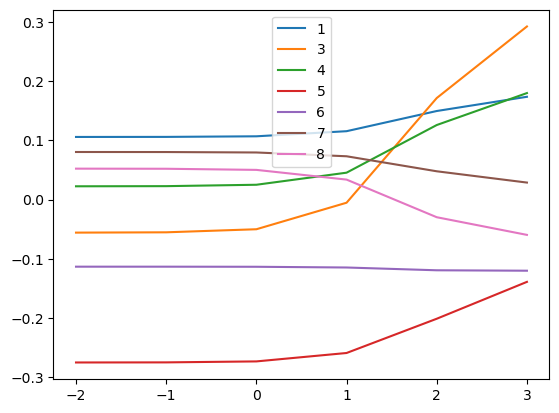

In [9]:
plt.figure()
coeff=[]
for lambdaa in [0.01, 0.1, 1, 10, 100, 1000]:
    clf=linear_model.Ridge(alpha=lambdaa)
    clf.fit(X_train,y_train)
    coef=clf.coef_
    coeff.append(coef)

coefs=np.array(coeff)

for i in [0,2,3,4,5,6,7]:
    plt.plot([-2,-1,0,1,2,3],coefs[:,i],label=i+1)

plt.legend()
plt.show()


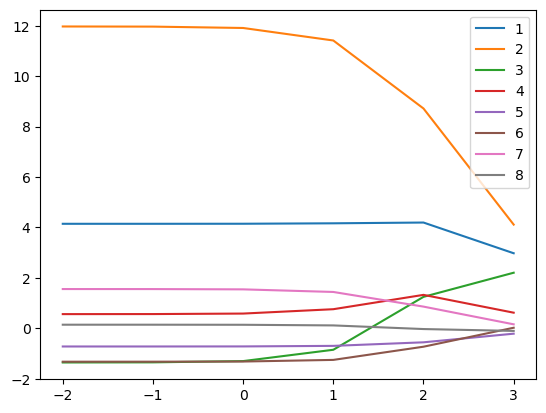

In [14]:
sca=sklearn.preprocessing.StandardScaler()
std_X_train=sca.fit_transform(X_train)
plt.figure()
coeff=[]
for lambdaa in [0.01, 0.1, 1, 10, 100, 1000]:
    clf=linear_model.Ridge(alpha=lambdaa)
    clf.fit(std_X_train,y_train)
    coef=clf.coef_
    coeff.append(coef)

coefs=np.array(coeff)

for i in [0,1,2,3,4,5,6,7]:
    plt.plot([-2,-1,0,1,2,3],coefs[:,i],label=i+1)

plt.legend()
plt.show()


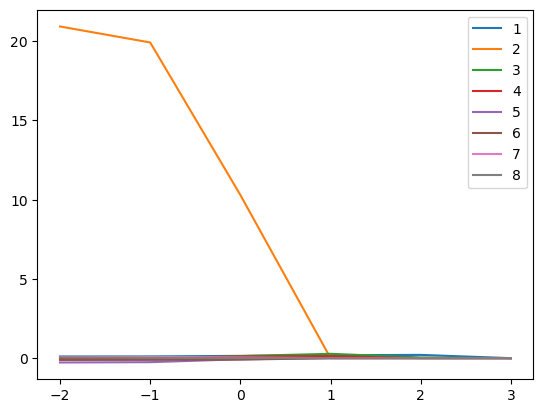

[[ 1.06245377e-01  2.09311463e+01 -5.38875422e-02  2.32840596e-02
  -2.73291737e-01 -1.12951440e-01  8.01993479e-02  4.90798777e-02]
 [ 1.09449195e-01  1.99218387e+01 -3.57407167e-02  3.07590946e-02
  -2.54278546e-01 -1.08741619e-01  7.77556706e-02  1.97699948e-02]
 [ 1.43241140e-01  1.02958228e+01  1.30149436e-01  1.00612435e-01
  -7.05280490e-02 -9.20987556e-02  4.26897863e-02 -0.00000000e+00]
 [ 1.86118844e-01  0.00000000e+00  2.73242197e-01  1.28610408e-01
  -0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00]
 [ 2.05031514e-01  0.00000000e+00  4.43179537e-02  0.00000000e+00
  -0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  -0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00]]


In [17]:
plt.figure()
coeff=[]
for lambdaa in [0.01, 0.1, 1, 10, 100, 1000]:
    clf=linear_model.Lasso(alpha=lambdaa)
    clf.fit(X_train,y_train)
    coef=clf.coef_
    coeff.append(coef)

coefs=np.array(coeff)

for i in [0,1,2,3,4,5,6,7]:
    plt.plot([-2,-1,0,1,2,3],coefs[:,i],label=i+1)

plt.legend()
plt.show()
print(coefs)


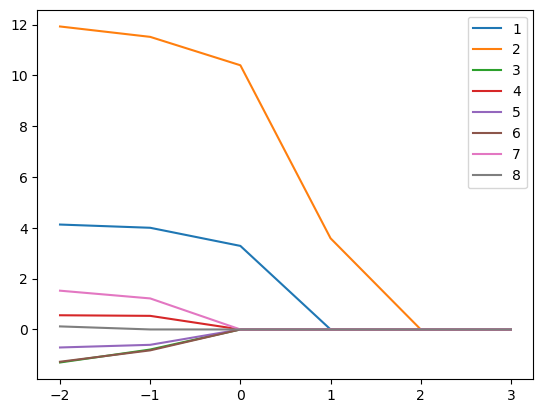

[[ 4.1295872  11.92666018 -1.30011303  0.55864965 -0.70938084 -1.27097122
   1.52629951  0.11990483]
 [ 4.00244362 11.51747889 -0.79059465  0.53528573 -0.60504222 -0.82310448
   1.22136333  0.        ]
 [ 3.28883178 10.39934404  0.          0.         -0.          0.
   0.          0.        ]
 [ 0.          3.5879545   0.          0.         -0.         -0.
   0.         -0.        ]
 [ 0.          0.          0.          0.         -0.         -0.
  -0.         -0.        ]
 [ 0.          0.          0.          0.         -0.         -0.
  -0.         -0.        ]]


In [19]:
plt.figure()
coeff=[]
for lambdaa in [0.01, 0.1, 1, 10, 100, 1000]:
    clf=linear_model.Lasso(alpha=lambdaa)
    clf.fit(std_X_train,y_train)
    coef=clf.coef_
    coeff.append(coef)

coefs=np.array(coeff)

for i in [0,1,2,3,4,5,6,7]:
    plt.plot([-2,-1,0,1,2,3],coefs[:,i],label=i+1)

plt.legend()
plt.show()
print(coefs)
